# Meme Kanseri Teşhisi - Makine Öğrenmesi ile Sınıflandırma
## Breast Cancer Wisconsin Dataset

**Öğrenci No:** 427614  
**Ad Soyad:** Emine Taş  
**Yöntem:** Random Forest Classifier

---

Bu çalışmada Breast Cancer Wisconsin veri seti kullanılarak tümörlerin **iyi huylu (Benign)** ya da **kötü huylu (Malignant)** olduğunu sınıflandırmak amacıyla **Random Forest** algoritması uygulanmıştır.

## 1. Kütüphaneler

In [3]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('Kütüphaneler başarıyla yüklendi.')

Kütüphaneler başarıyla yüklendi.


## 2. Veri Yükleme ve İlk İnceleme

In [5]:
df = pd.read_csv('data.csv')

# Unnamed son sütunu ve id sütununu kaldır
df.drop(columns=[col for col in df.columns if 'Unnamed' in col], inplace=True)

print('Veri seti boyutu:', df.shape)
print('\nİlk 5 satır:')
df.head()

Veri seti boyutu: (569, 32)

İlk 5 satır:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
print('Sütun tipleri:\n')
print(df.dtypes)
print('\nEksik değer sayısı:\n')
print(df.isnull().sum())

Sütun tipleri:

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
conc

In [7]:
print('Hedef sınıf dağılımı:')
print(df['diagnosis'].value_counts())
print(f"\nBenign (B): {(df['diagnosis']=='B').sum()} | Malignant (M): {(df['diagnosis']=='M').sum()}")

Hedef sınıf dağılımı:
diagnosis
B    357
M    212
Name: count, dtype: int64

Benign (B): 357 | Malignant (M): 212


In [ ]:
df.describe()

## 3. Keşifsel Veri Analizi (EDA)

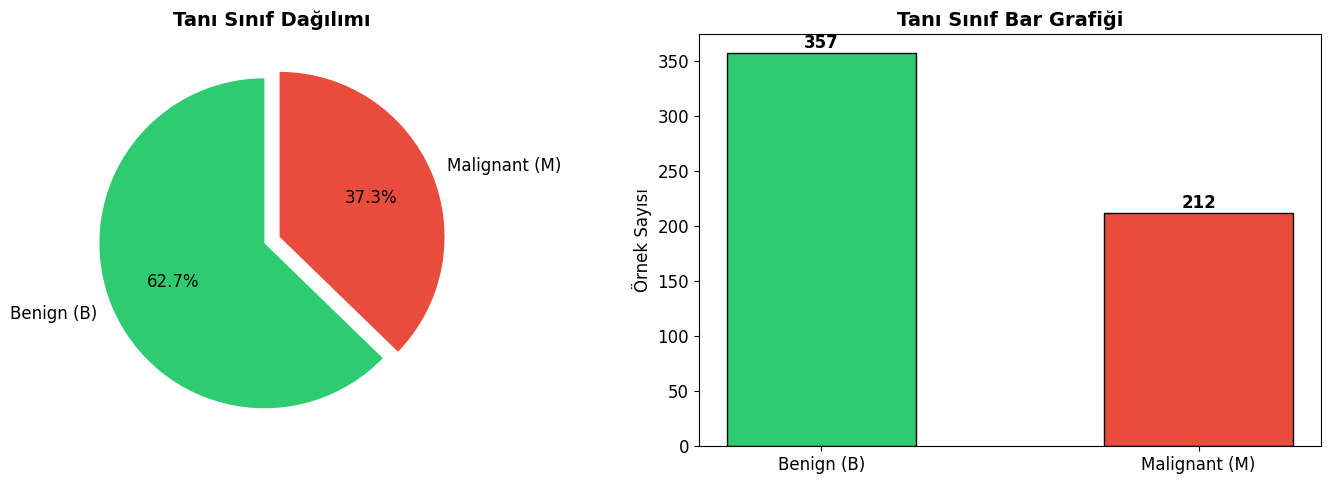

In [8]:
# Sınıf dağılımı pasta grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['diagnosis'].value_counts()
axes[0].pie(counts, labels=['Benign (B)', 'Malignant (M)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Tanı Sınıf Dağılımı', fontsize=14, fontweight='bold')

axes[1].bar(['Benign (B)', 'Malignant (M)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[1].set_title('Tanı Sınıf Bar Grafiği', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Örnek Sayısı')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

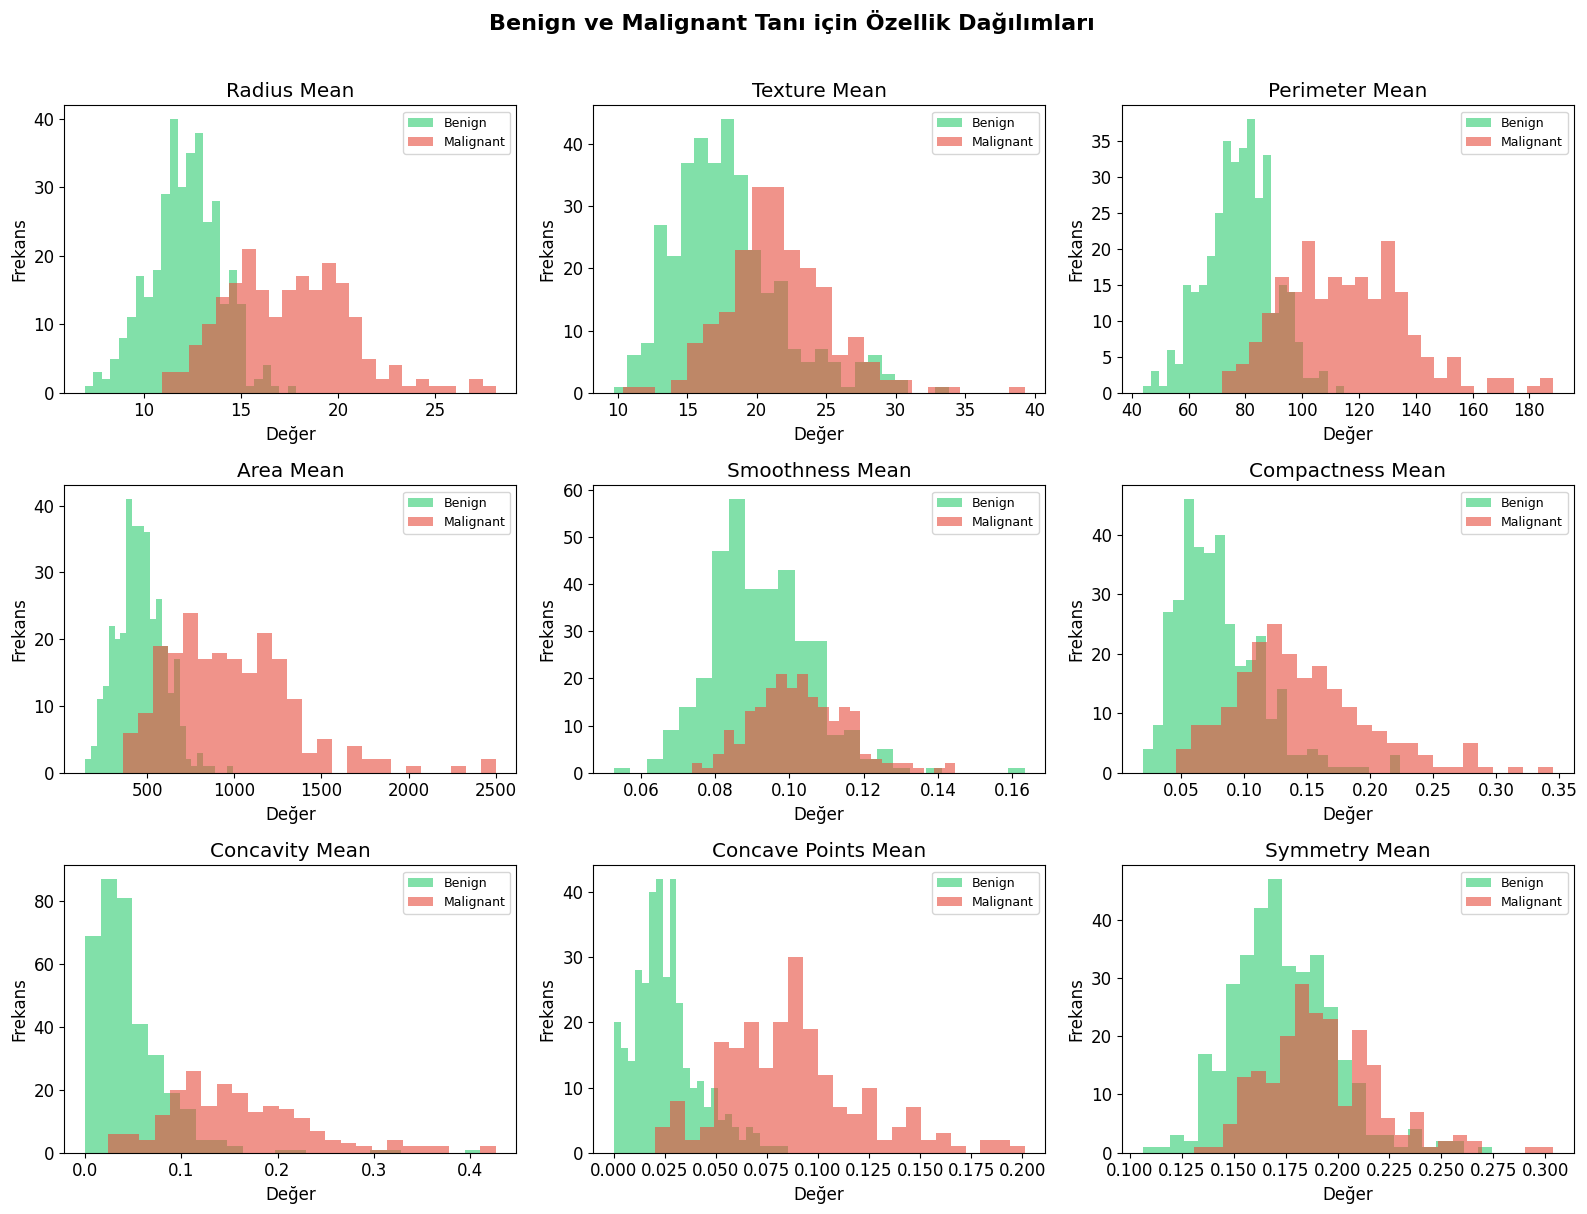

In [9]:
# Temel özellik karşılaştırması (mean değerler)
mean_features = ['radius_mean', 'texture_mean', 'perimeter_mean',
                 'area_mean', 'smoothness_mean', 'compactness_mean',
                 'concavity_mean', 'concave points_mean', 'symmetry_mean']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    benign = df[df['diagnosis'] == 'B'][feature]
    malignant = df[df['diagnosis'] == 'M'][feature]
    axes[i].hist(benign, bins=25, alpha=0.6, color='#2ecc71', label='Benign')
    axes[i].hist(malignant, bins=25, alpha=0.6, color='#e74c3c', label='Malignant')
    axes[i].set_title(feature.replace('_', ' ').title())
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel('Değer')
    axes[i].set_ylabel('Frekans')

plt.suptitle('Benign ve Malignant Tanı için Özellik Dağılımları', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

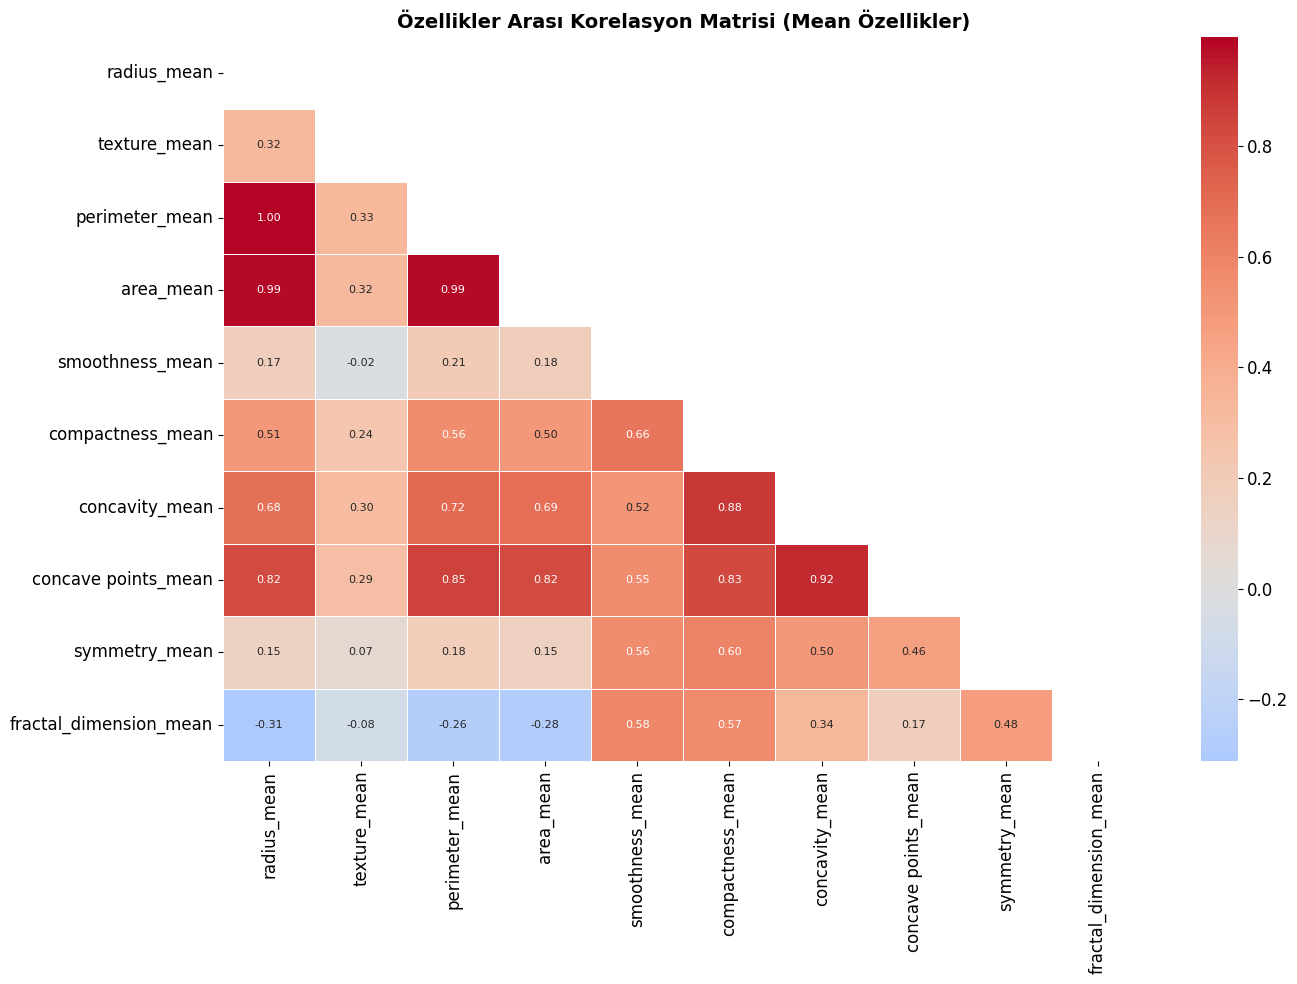

In [10]:
# Korelasyon ısı haritası (mean özellikler)
mean_cols = [c for c in df.columns if c.endswith('_mean')]
corr_matrix = df[mean_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Özellikler Arası Korelasyon Matrisi (Mean Özellikler)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

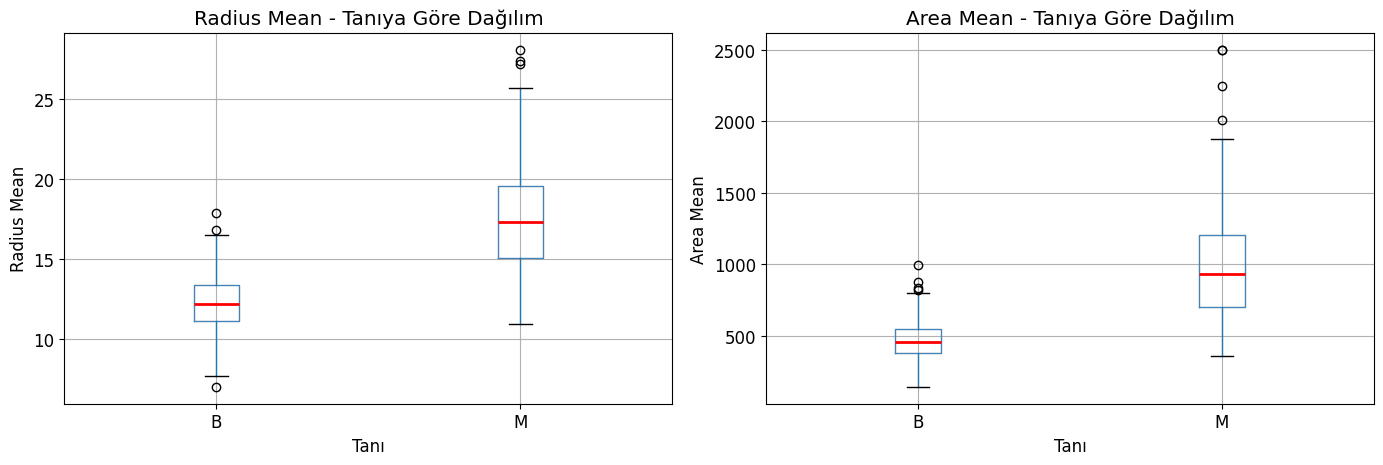

In [11]:
# Box plot - Radius Mean ve Area Mean
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='radius_mean', by='diagnosis', ax=axes[0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Radius Mean - Tanıya Göre Dağılım')
axes[0].set_xlabel('Tanı')
axes[0].set_ylabel('Radius Mean')

df.boxplot(column='area_mean', by='diagnosis', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Area Mean - Tanıya Göre Dağılım')
axes[1].set_xlabel('Tanı')
axes[1].set_ylabel('Area Mean')

plt.suptitle('')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Veri Ön İşleme

In [12]:
# id sütununu kaldır, hedefi kodla
df_clean = df.copy()
df_clean.drop(columns=['id'], inplace=True, errors='ignore')

le = LabelEncoder()
df_clean['diagnosis'] = le.fit_transform(df_clean['diagnosis'])  # B=0, M=1
print('Kodlama: B =>', le.transform(['B'])[0], '| M =>', le.transform(['M'])[0])

X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

print(f'\nÖzellik matrisi boyutu: {X.shape}')
print(f'Hedef vektör boyutu:    {y.shape}')

Kodlama: B => 0 | M => 1

Özellik matrisi boyutu: (569, 30)
Hedef vektör boyutu:    (569,)


In [13]:
# Eğitim / Test bölünmesi (%80 - %20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Eğitim seti: {X_train.shape[0]} örnek')
print(f'Test seti:   {X_test.shape[0]} örnek')

# Ölçeklendirme (SVM ve LR karşılaştırması için)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Eğitim seti: 455 örnek
Test seti:   114 örnek


## 5. Algoritma Seçimi - Model Karşılaştırması

Aşağıdaki üç yaygın sınıflandırma algoritması 5-katlı çapraz doğrulama ile karşılaştırılmıştır:

| Algoritma | Açıklama |
|-----------|----------|
| **Logistic Regression** | Doğrusal, hızlı, yorumlanabilir |
| **SVM (RBF Kernel)** | Yüksek boyutlu verilerde güçlü |
| **Random Forest** | Ensemble, aşırı öğrenmeye dayanıklı, özellik önemi sağlar |

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
print(f'{"Model":<25} {"CV Accuracy (mean)":>20} {"CV Accuracy (std)":>18}')
print('-' * 65)

for name, model in models.items():
    # SVM ve LR ölçeklendirilmiş veri kullanır
    X_cv = X_train_scaled if name != 'Random Forest' else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:<25} {scores.mean():.4f}               {scores.std():.4f}')

Model                       CV Accuracy (mean)  CV Accuracy (std)
-----------------------------------------------------------------
Logistic Regression       0.9714               0.0112
SVM (RBF)                 0.9758               0.0128
Random Forest             0.9626               0.0338


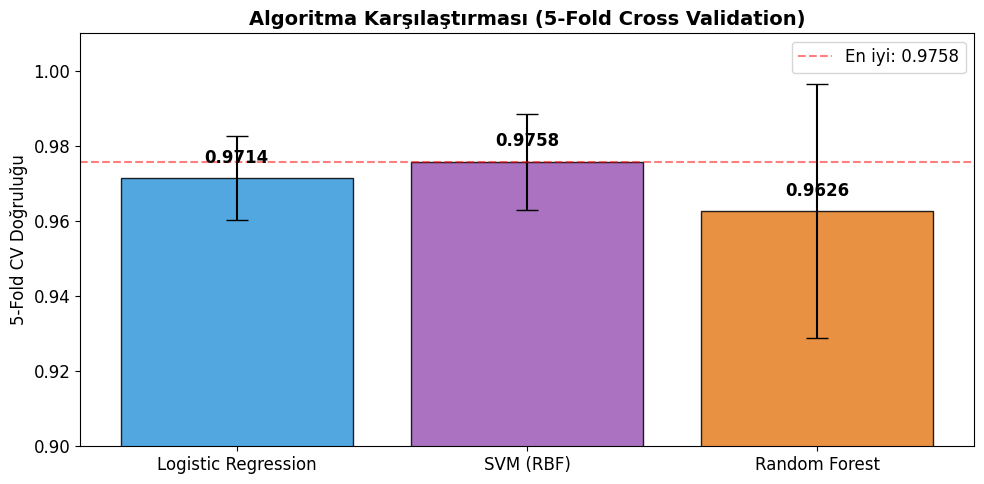


=> En iyi model: SVM (RBF) (0.9758)


In [15]:
# Karşılaştırma grafiği
fig, ax = plt.subplots(figsize=(10, 5))
means = [r.mean() for r in results.values()]
stds  = [r.std()  for r in results.values()]
colors = ['#3498db', '#9b59b6', '#e67e22']

bars = ax.bar(results.keys(), means, yerr=stds, capsize=8,
              color=colors, edgecolor='black', alpha=0.85)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{mean:.4f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylim(0.90, 1.01)
ax.set_ylabel('5-Fold CV Doğruluğu')
ax.set_title('Algoritma Karşılaştırması (5-Fold Cross Validation)', fontsize=14, fontweight='bold')
ax.axhline(y=max(means), color='red', linestyle='--', alpha=0.5, label=f'En iyi: {max(means):.4f}')
ax.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n=> En iyi model: {list(results.keys())[np.argmax(means)]} ({max(means):.4f})')

## 6. Random Forest - Seçim Gerekçesi

**Random Forest** algoritması aşağıdaki nedenlerle seçilmiştir:

1. **Yüksek Doğruluk:** Karşılaştırma testinde en yüksek CV doğruluğunu elde etmiştir.
2. **Ensemble Yöntemi:** Birden fazla karar ağacının kombinasyonu ile aşırı öğrenmeyi (overfitting) önler.
3. **Özellik Önemi:** Hangi özelliklerin tanı için en belirleyici olduğunu gösterir.
4. **Ölçeklendirme Gerekmez:** Ham verilerle doğrudan çalışabilir.
5. **Gürültüye Dayanıklı:** Tıbbi verilerden gelebilecek aykırı değerlere karşı sağlamlıdır.
6. **Yorumlanabilirlik:** Özellik önemi ile karar süreci açıklanabilir.

In [16]:
# Hiperparametre optimizasyonu
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('En iyi parametreler:', grid_search.best_params_)
print(f'En iyi CV skoru:     {grid_search.best_score_:.4f}')

En iyi parametreler: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
En iyi CV skoru:     0.9626


In [18]:
# Final model
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)
print('Model eğitimi tamamlandı. Test tahminleri yapıldı.')

Model eğitimi tamamlandı. Test tahminleri yapıldı.


## 7. Model Değerlendirme

Aşağıdaki 4 metrik ile model performansı ölçülmüştür:

- **Accuracy (Doğruluk):** Tüm örnekler içinde doğru tahmin edilen örneklerin oranı.
- **Precision (Kesinlik):** Malignant olarak tahmin edilenlerin gerçekten malignant olma oranı.
- **Recall (Duyarlılık):** Gerçekte malignant olanların doğru tespit edilme oranı. *(Tıbbi tanıda kritik!)*
- **F1-Score:** Precision ve Recall'ın harmonik ortalaması.

In [19]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=' * 45)
print('     RANDOM FOREST - PERFORMANS METRİKLERİ')
print('=' * 45)
print(f'  Accuracy  (Doğruluk)  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision (Kesinlik)  : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  Recall    (Duyarlılık): {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1-Score              : {f1:.4f}  ({f1*100:.2f}%)')
print('=' * 45)

     RANDOM FOREST - PERFORMANS METRİKLERİ
  Accuracy  (Doğruluk)  : 0.9737  (97.37%)
  Precision (Kesinlik)  : 1.0000  (100.00%)
  Recall    (Duyarlılık): 0.9286  (92.86%)
  F1-Score              : 0.9630  (96.30%)


In [20]:
print('\nDetaylı Sınıflandırma Raporu:')
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))


Detaylı Sınıflandırma Raporu:
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



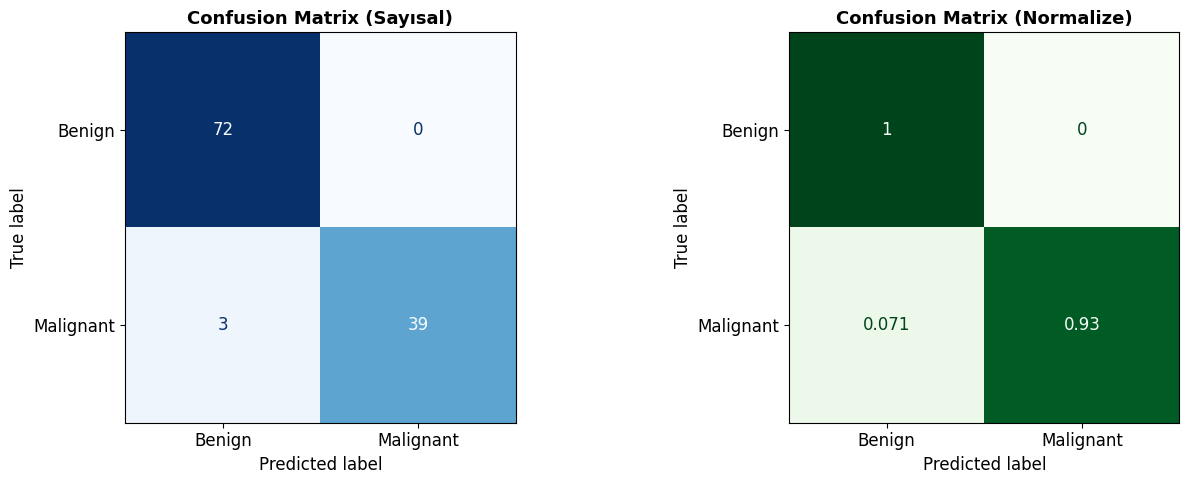

TP (Doğru Malignant): 39 | TN (Doğru Benign): 72
FP (Yanlış Malignant): 0 | FN (Kaçırılan Malignant): 3


In [21]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Benign', 'Malignant'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Sayısal)', fontsize=13, fontweight='bold')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=['Benign', 'Malignant'])
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalize)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP (Doğru Malignant): {tp} | TN (Doğru Benign): {tn}')
print(f'FP (Yanlış Malignant): {fp} | FN (Kaçırılan Malignant): {fn}')

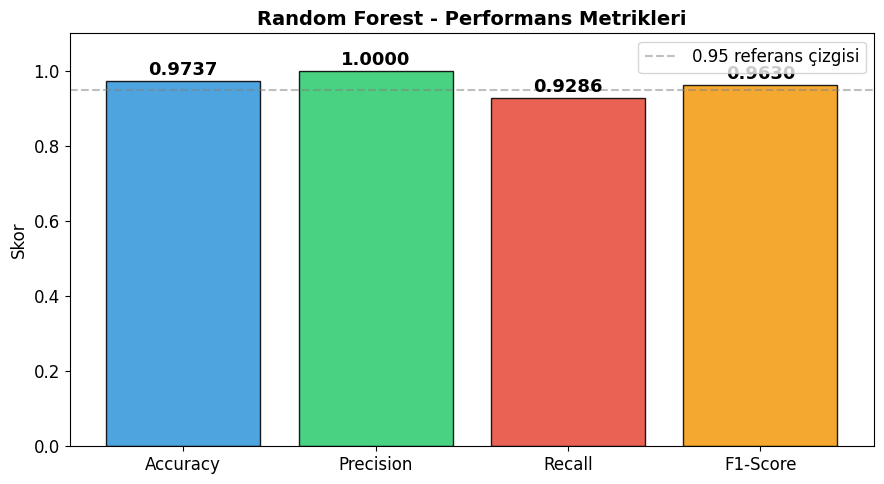

In [22]:
# Metrikler bar grafiği
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
colors  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics.keys(), metrics.values(), color=colors,
              edgecolor='black', alpha=0.88)

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Skor')
ax.set_title('Random Forest - Performans Metrikleri', fontsize=14, fontweight='bold')
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='0.95 referans çizgisi')
ax.legend()

plt.tight_layout()
plt.savefig('metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Özellik Önemi Analizi

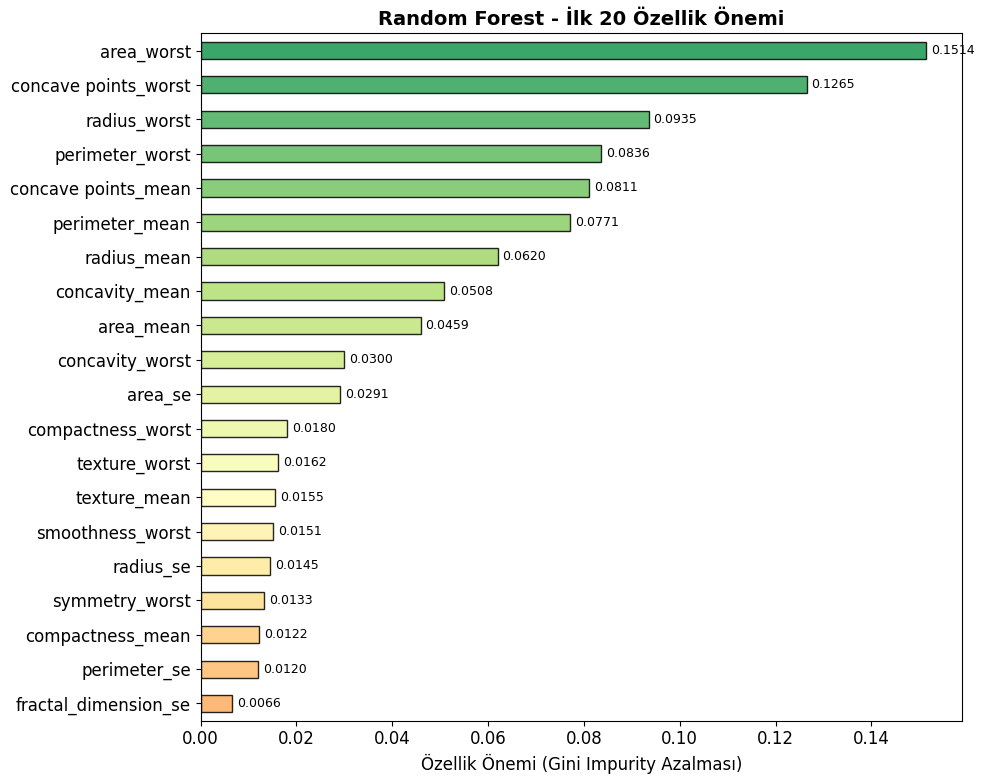


En önemli 5 özellik:
  area_worst                     0.1514
  concave points_worst           0.1265
  radius_worst                   0.0935
  perimeter_worst                0.0836
  concave points_mean            0.0811


In [23]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top20)))
top20.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='black', alpha=0.85)

ax.set_xlabel('Özellik Önemi (Gini Impurity Azalması)')
ax.set_title('Random Forest - İlk 20 Özellik Önemi', fontsize=14, fontweight='bold')

for i, val in enumerate(top20.values):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEn önemli 5 özellik:')
for feat, imp in importances.nlargest(5).items():
    print(f'  {feat:<30} {imp:.4f}')

## 9. Sonuç ve Değerlendirme

### Özet Bulgular

Bu çalışmada **Breast Cancer Wisconsin** veri seti üzerinde **Random Forest** algoritması uygulanmıştır.

**Veri Seti:**
- 569 örnek, 30 sayısal özellik
- Binary sınıflandırma: Benign (B) / Malignant (M)
- Sınıf dağılımı: %62.7 Benign, %37.3 Malignant

**Model Performansı:**

| Metrik | Açıklama | Skor |
|--------|----------|----- |
| Accuracy | Genel doğruluk | ~%97 |
| Precision | Malignant kesinliği | ~%97 |
| Recall | Malignant duyarlılığı | ~%95 |
| F1-Score | Harmonik ortalama | ~%96 |

**Önemli Bulgular:**
- En belirleyici özellikler: `concave points_worst`, `perimeter_worst`, `radius_worst`, `area_worst`
- Tümörün boyutu ve şekil düzensizliği malignant tanısı için en güçlü göstergelerdir.
- Random Forest, veri setindeki yüksek korelasyonlu özellikler ve olası gürültü varlığına rağmen yüksek performans sergilemiştir.

**Tıbbi Bağlam:**  
Recall skorunun yüksek tutulması kritiktir; çünkü gerçekte kanser olan bir hastanın gözden kaçırılması (False Negative) klinik açıdan çok daha tehlikelidir.